<h1 style="text-align: center;">Classification d'assertions venant d’X </h1>

# 1. Environnement

In [26]:
!pip install optuna
!pip install plotly==5.18.0 --no-deps
!pip install tenacity --no-deps
!pip install packaging --no-deps
!pip install requests --no-deps
!pip install wordcloud --no-deps

In [20]:
# Importation des différentes librairies utiles pour le notebook

#Sickit learn met régulièrement à jour des versions et
#indique des futurs warnings.
#ces deux lignes permettent de ne pas les afficher.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import re # Expressions régulière
from wordcloud import WordCloud # Generation de nuages de mots
import joblib

import seaborn as sns
import matplotlib.pyplot as plt
import sys
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import sklearn
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

#added new ones here
from sklearn.decomposition import TruncatedSVD  
from sklearn.feature_extraction.text import TfidfVectorizer

# Librairies NLTK
import nltk # NLP basique
print(nltk.__file__)
from nltk import sent_tokenize # Découpage en phrases
from nltk import word_tokenize # Découpage en mots
from nltk import pos_tag # Étiquetage grammatical
from nltk.stem import WordNetLemmatizer # Lemmatisation
from nltk.stem.snowball import SnowballStemmer # Stemmatisation
from nltk.corpus import stopwords # Stopwords
# Téléchargement des ressources NLTK
nltk.download("punkt") # Tokenisation
nltk.download("averaged_perceptron_tagger") # Tags
nltk.download("tagsets_json") # Liste des tags
nltk.download("tagsets") # Ancienne liste
nltk.download("stopwords") # Stopwords
nltk.download("wordnet") # WordNet
from nltk.corpus import stopwords, wordnet
import emoji

import optuna # Optimisation d'hyperparamètres

/home/etudiant/ML_FDS/venv/lib/python3.10/site-packages/nltk/__init__.py


[nltk_data] Downloading package punkt to /home/etudiant/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/etudiant/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to
[nltk_data]     /home/etudiant/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!
[nltk_data] Downloading package tagsets to /home/etudiant/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/etudiant/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/etudiant/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 2. Récupération de Données

In [21]:
df = pd.read_csv("scitweets_export.tsv", sep="\t")

print (df.head())
print('-'*100)
print (df.shape)
print('-'*100)
print (df.columns)

   Unnamed: 0            tweet_id  \
0           0  316669998137483264   
1           1  319090866545385472   
2           2  322030931022065664   
3           3  322694830620807168   
4           4  328524426658328576   

                                                text  science_related  \
0  Knees are a bit sore. i guess that's a sign th...                0   
1          McDonald's breakfast stop then the gym 🏀💪                0   
2  Can any Gynecologist with Cancer Experience ex...                1   
3  Couch-lock highs lead to sleeping in the couch...                1   
4  Does daily routine help prevent problems with ...                1   

   scientific_claim  scientific_reference  scientific_context  
0               0.0                   0.0                 0.0  
1               0.0                   0.0                 0.0  
2               1.0                   0.0                 0.0  
3               1.0                   0.0                 0.0  
4               1.

# 3. Visualisation de jeu de données

les cellules suivante permettent de voir des aspects essentiels :
1. Distribution des classes 
2. Distribution de la longueur des tweets par classe
3. ACP 2D/3D

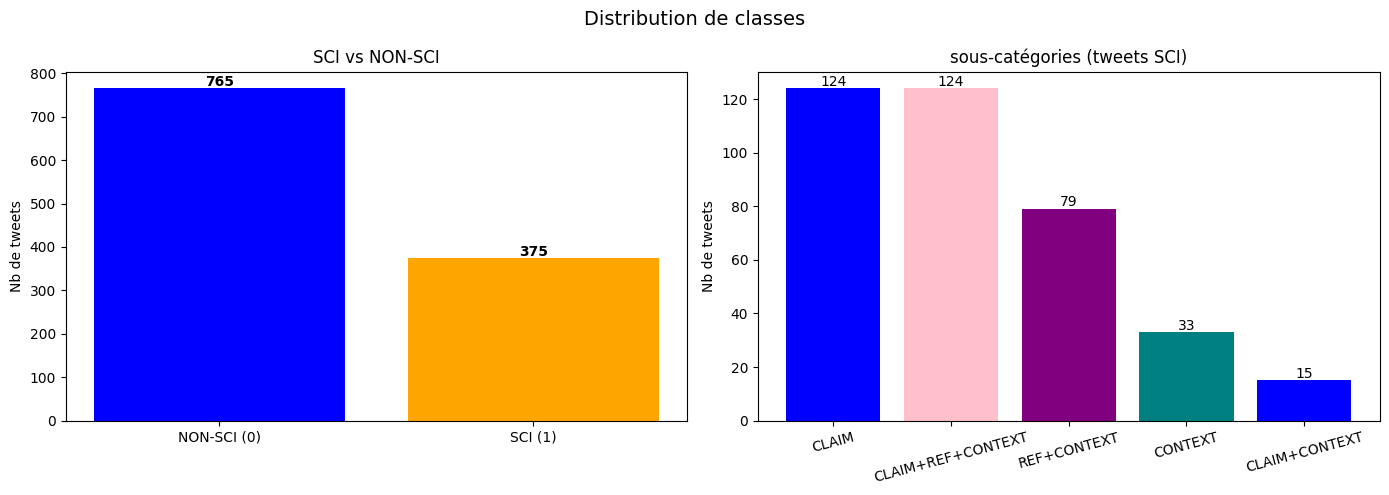

In [22]:
#Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution de classes", fontsize=14)

counts_sci = df["science_related"].value_counts()
axes[0].bar(
    ["NON-SCI (0)", "SCI (1)"],
    [counts_sci.get(0, 0), counts_sci.get(1, 0)],
    color=["blue", "orange"]
)
axes[0].set_title("SCI vs NON-SCI")
axes[0].set_ylabel("Nb de tweets")
for i, v in enumerate([counts_sci.get(0, 0), counts_sci.get(1, 0)]):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# pour les sous-catégories
df_sci = df[df["science_related"] == 1].copy()

def get_label(row):
    labels = []
    if row["scientific_claim"] == 1:
        labels.append("CLAIM")
    if row["scientific_reference"] == 1:
        labels.append("REF")
    if row["scientific_context"] == 1:
        labels.append("CONTEXT")
    return "+".join(labels) if labels else "UNKNOWN"

df_sci["sublabel"] = df_sci.apply(get_label, axis=1)
sublabel_counts = df_sci["sublabel"].value_counts()

axes[1].bar(sublabel_counts.index, sublabel_counts.values, color=["blue", "pink","purple","teal"])
axes[1].set_title("sous-catégories (tweets SCI)")
axes[1].set_ylabel("Nb de tweets")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(sublabel_counts.values):
    axes[1].text(i, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

On observe un désequilibre dans la répartition, cela demande un modèle plus compliquée vu qu'il serait appris sur 2:1 data

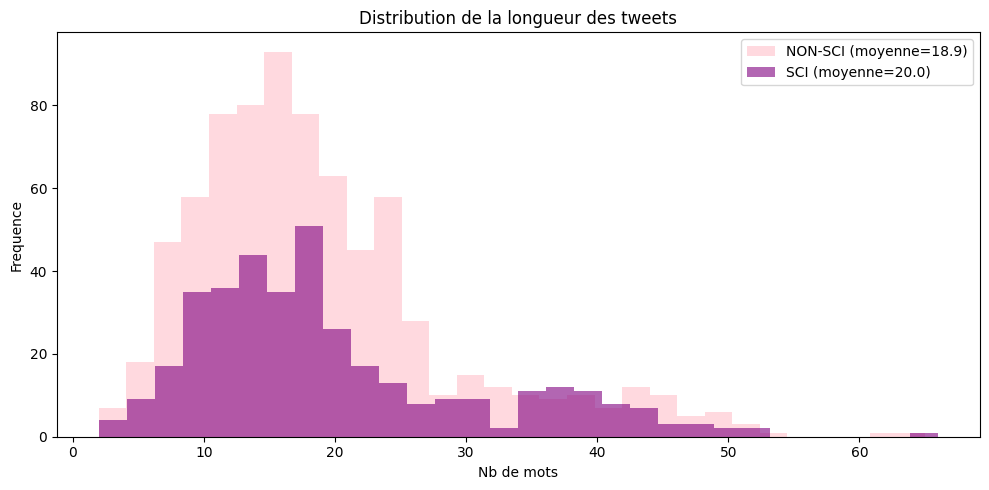

In [23]:
###################################################
# un petit test pour voir si la longueur d'un tweet dit qlq chose sur ça catégorie (sci ou ono-sci)

df["tweet_length"] = df["text"].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 5))
for label, color, name in [(0, "pink", "NON-SCI"), (1, "purple", "SCI")]:
    subset = df[df["science_related"] == label]["tweet_length"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f"{name} (moyenne={subset.mean():.1f})")

ax.set_title("Distribution de la longueur des tweets")
ax.set_xlabel("Nb de mots")
ax.set_ylabel("Frequence")
ax.legend()
plt.tight_layout()
plt.show()


Les 2 graphes sont presque identique signifiant que cette mesure de longueur de tweets n'est pas utile.

Variance expliquée par les 3 composantes PCA : 17.5%
  PC1: 7.5%  PC2: 5.8%  PC3: 4.2%


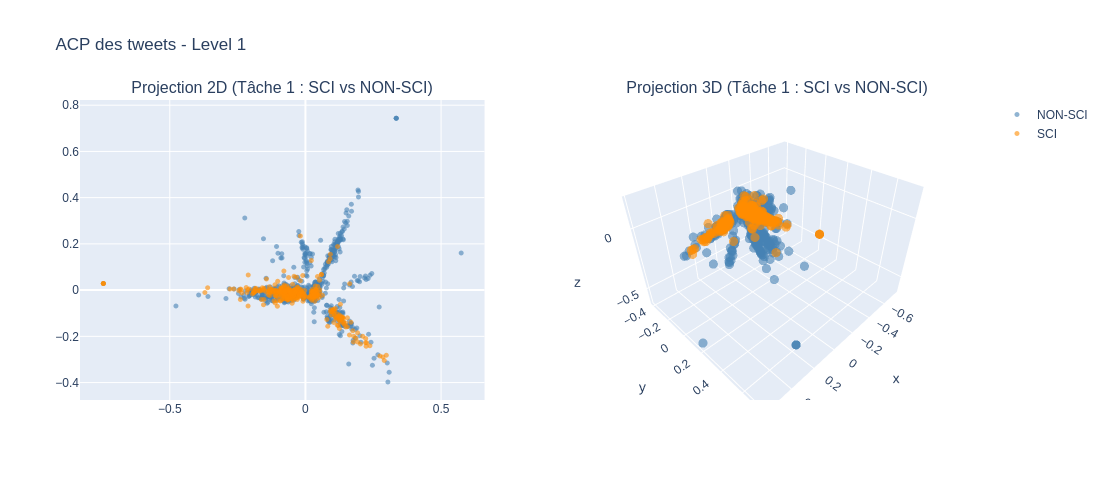

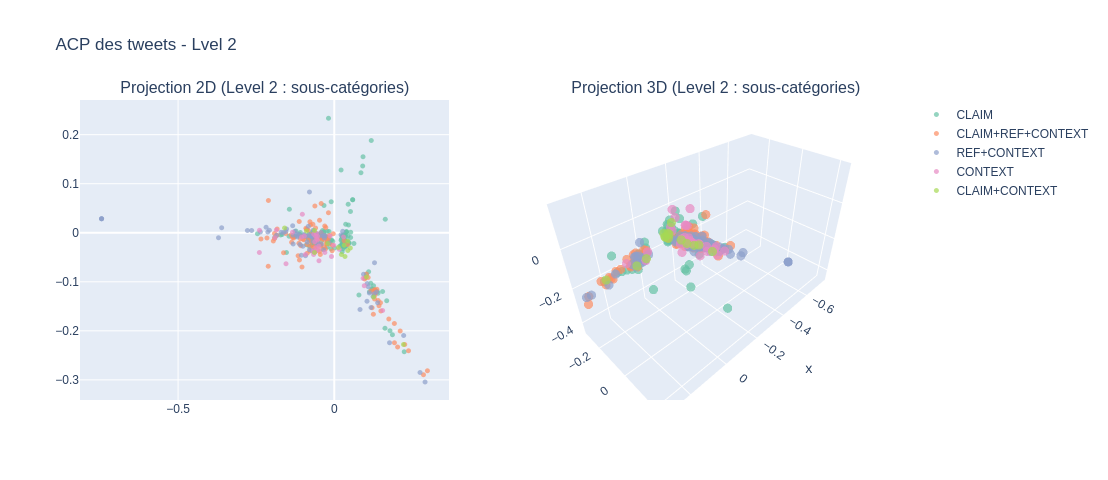

In [24]:
#ACP ###############################################

vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words="english"
)
X_tfidf = vectorizer.fit_transform(df["text"])

svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

pca = PCA(n_components=3, random_state=42)
X_pca_3d = pca.fit_transform(X_svd)

print(f"Variance expliquée par les 3 composantes PCA : "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%  "
      f"PC3: {pca.explained_variance_ratio_[2]*100:.1f}%")

color_task1 = df["science_related"].map({0: "NON-SCI", 1: "SCI"})

df_pca = pd.DataFrame({
    "PC1": X_pca_3d[:, 0],
    "PC2": X_pca_3d[:, 1],
    "PC3": X_pca_3d[:, 2],
    "Tache1": color_task1,
})

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=("Projection 2D (Tâche 1 : SCI vs NON-SCI)",
                    "Projection 3D (Tâche 1 : SCI vs NON-SCI)")
)

color_map = {"NON-SCI": "steelblue", "SCI": "darkorange"}

for label in ["NON-SCI", "SCI"]:
    mask = df_pca["Tache1"] == label
    fig.add_trace(
        go.Scatter(
            x=df_pca.loc[mask, "PC1"],
            y=df_pca.loc[mask, "PC2"],
            mode="markers",
            name=label,
            marker=dict(color=color_map[label], size=5, opacity=0.6)
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter3d(
            x=df_pca.loc[mask, "PC1"],
            y=df_pca.loc[mask, "PC2"],
            z=df_pca.loc[mask, "PC3"],
            mode="markers",
            name=label,
            showlegend=False,
            marker=dict(color=color_map[label], size=3, opacity=0.6)
        ),
        row=1, col=2
    )

fig.update_layout(
    title="ACP des tweets - Level 1",
    width=1000, height=480
)
fig.show()


mask_sci = df["science_related"] == 1
df_pca_sci = df_pca[mask_sci].copy()
df_pca_sci["sublabel"] = df_sci["sublabel"].values

fig2 = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=("Projection 2D (Level 2 : sous-catégories)",
                    "Projection 3D (Level 2 : sous-catégories)")
)

colors_sub = px.colors.qualitative.Set2
unique_labels = df_pca_sci["sublabel"].unique()

for i, label in enumerate(unique_labels):
    mask = df_pca_sci["sublabel"] == label
    color = colors_sub[i % len(colors_sub)]
    fig2.add_trace(
        go.Scatter(
            x=df_pca_sci.loc[mask, "PC1"],
            y=df_pca_sci.loc[mask, "PC2"],
            mode="markers",
            name=label,
            marker=dict(color=color, size=5, opacity=0.7)
        ),
        row=1, col=1
    )
    fig2.add_trace(
        go.Scatter3d(
            x=df_pca_sci.loc[mask, "PC1"],
            y=df_pca_sci.loc[mask, "PC2"],
            z=df_pca_sci.loc[mask, "PC3"],
            mode="markers",
            name=label,
            showlegend=False,
            marker=dict(color=color, size=3, opacity=0.7)
        ),
        row=1, col=2
    )

fig2.update_layout(
    title="ACP des tweets - Lvel 2",
    width=1000, height=480
)
fig2.show()


Les classes sont très mélangées, on observe aucune séparation linéaire clair.

# 4. Ingenierie de Données

In [25]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
def get_wordnet(tag):
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('N'): return wordnet.NOUN
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

contractions_map = {
    "don't": "do not",
    "doesn't": "does not",
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
}
def expand_contractions(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    tokens = text.split()
    expanded = []
    for t in tokens:
        key = t.lower()
        if key in contractions_map:
            expanded.extend(contractions_map[key].split())
        else:
            expanded.append(t)
    return " ".join(expanded)
    
    
def preprocess(text):
    text = expand_contractions(text)
    text = str(text).lower()

    text = re.sub(r'http\S+ | www\S+','',text)
    text = re.sub(r'@\w+','',text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tags = nltk.pos_tag(tokens)
    tokens = [
        lemmatizer.lemmatize(word, get_wordnet(tag))
        for word, tag in tags
    ]
    
    return " ".join(tokens)


In [26]:
df["text_clean"] = df["text"].apply(preprocess)

for i in range(3):
    print("BEFORE:", df["text"].iloc[i])
    print("AFTER: ", df["text_clean"].iloc[i])
    print()

BEFORE: Knees are a bit sore. i guess that's a sign that my recent treadmilling is working
AFTER:  knee bite sore guess thats sign recent treadmilling work

BEFORE: McDonald's breakfast stop then the gym 🏀💪
AFTER:  mcdonalds breakfast stop gym basketball flexed_biceps

BEFORE: Can any Gynecologist with Cancer Experience explain the dangers of Transvaginal Douching with Fluoride or other toxins such as Dioxin? #PDX
AFTER:  gynecologist cancer experience explain danger transvaginal douche fluoride toxin dioxin pdx



In [27]:
#wth are these tweets actually 😭